In [11]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Caminho base dos dados
BASE = r"C:\Users\lucas\OneDrive\Área de Trabalho\Projetos\city-analysis\CDAF - bases de dados e codigos de apoio\Wyscout"

CITY_ID = 1625

In [12]:
df_events = pd.DataFrame()
for i in range(1, 14):
    path = os.path.join(BASE, f'events_England_{i}.json')
    with open(path) as f:
        data = json.load(f)
    df_events = pd.concat([df_events, pd.DataFrame(data)])

print(f"Total de eventos: {len(df_events)}")
print(df_events['eventName'].value_counts())

Total de eventos: 643150
eventName
Pass                       328657
Duel                       176688
Others on the ball          51085
Free Kick                   36423
Interruption                27535
Shot                         8451
Foul                         8138
Save attempt                 3349
Offside                      1558
Goalkeeper leaving line      1266
Name: count, dtype: int64


In [13]:
with open(os.path.join(BASE, 'matches_England.json')) as f:
    matches = json.load(f)
df_matches = pd.DataFrame(matches)

# Jogos onde o City participou
city_matches = df_matches[
    (df_matches['teamsData'].apply(lambda x: str(CITY_ID) in str(x)))
]
city_match_ids = city_matches['wyId'].tolist()
print(f"Jogos do Man City encontrados: {len(city_match_ids)}")

Jogos do Man City encontrados: 38


In [14]:
# Eventos defensivos nos jogos do City
eventos_city = df_events[df_events['matchId'].isin(city_match_ids)].copy()

# Extrair coordenada X de início do evento
def get_x(positions):
    try:
        return positions[0]['x']
    except:
        return None

eventos_city['x'] = eventos_city['positions'].apply(get_x)

# Pegar só eventos do ADVERSÁRIO (não do City)
# e só ações defensivas
eventos_adversario = eventos_city[
    (eventos_city['teamId'] != CITY_ID) &
    (eventos_city['eventName'].isin(['Duel', 'Interruption', 'Free Kick']))
].copy()

# Calcular mediana do X por jogo
altura_bloco = eventos_adversario.groupby('matchId')['x'].median().reset_index()
altura_bloco.columns = ['matchId', 'mediana_x']

# Classificar bloco (X alto = defende perto do City = bloco baixo)
altura_bloco['tipo_bloco'] = pd.cut(
    altura_bloco['mediana_x'],
    bins=[0, 39, 46, 100],
    labels=['Bloco Alto', 'Bloco Médio', 'Bloco Baixo']
)

print(altura_bloco['tipo_bloco'].value_counts())
altura_bloco.head(10)

tipo_bloco
Bloco Alto     15
Bloco Médio    13
Bloco Baixo    10
Name: count, dtype: int64


,matchId,mediana_x,tipo_bloco
0,2499720,35.0,Bloco Alto
1,2499734,57.0,Bloco Baixo
2,2499739,37.0,Bloco Alto
3,2499754,43.0,Bloco Médio
4,2499767,34.5,Bloco Alto
5,2499774,39.5,Bloco Médio
6,2499781,39.0,Bloco Alto
7,2499794,39.0,Bloco Alto
8,2499802,49.0,Bloco Baixo
9,2499818,40.0,Bloco Médio


In [15]:
eventos_city_ataque = eventos_city[eventos_city['teamId'] == CITY_ID].copy()

kpis = eventos_city_ataque.groupby('matchId').agg(
    total_passes=('eventName', lambda x: (x == 'Pass').sum()),
    total_chutes=('eventName', lambda x: (x == 'Shot').sum()),
).reset_index()

# Juntar com altura do bloco
df_analise = altura_bloco.merge(kpis, on='matchId')
df_analise.head()

,matchId,mediana_x,tipo_bloco,total_passes,total_chutes
0,2499720,35.0,Bloco Alto,754,12
1,2499734,57.0,Bloco Baixo,521,18
2,2499739,37.0,Bloco Alto,606,17
3,2499754,43.0,Bloco Médio,717,13
4,2499767,34.5,Bloco Alto,631,25


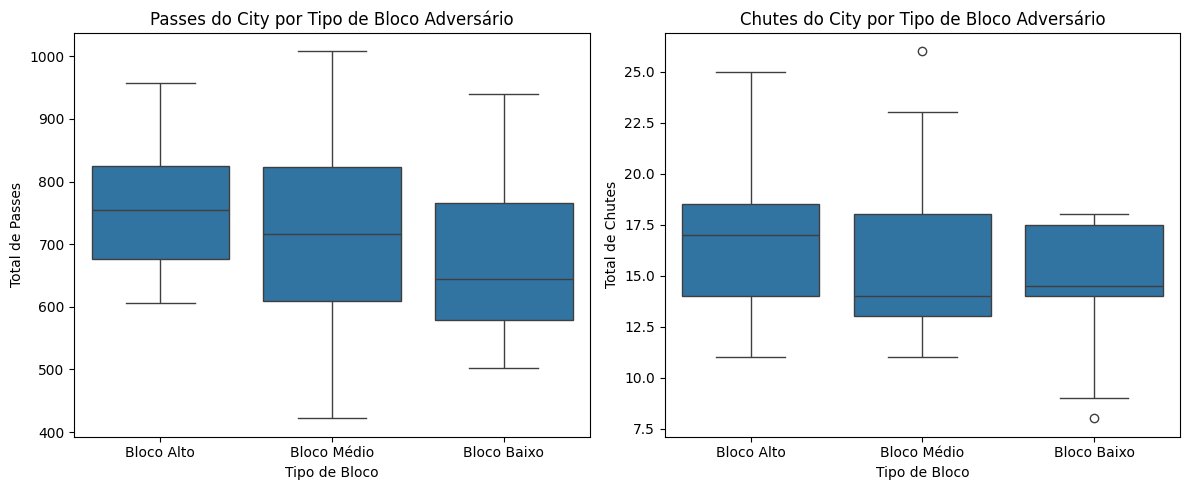

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Passes por tipo de bloco
sns.boxplot(data=df_analise, x='tipo_bloco', y='total_passes', ax=axes[0])
axes[0].set_title('Passes do City por Tipo de Bloco Adversário')
axes[0].set_xlabel('Tipo de Bloco')
axes[0].set_ylabel('Total de Passes')

# Chutes por tipo de bloco
sns.boxplot(data=df_analise, x='tipo_bloco', y='total_chutes', ax=axes[1])
axes[1].set_title('Chutes do City por Tipo de Bloco Adversário')
axes[1].set_xlabel('Tipo de Bloco')
axes[1].set_ylabel('Total de Chutes')

plt.tight_layout()
plt.savefig('analise_city.png', dpi=150)
plt.show()

In [17]:
# Ver a distribuição geral do X dos eventos adversários
print(eventos_adversario['x'].describe())
print()
# Ver exemplos de um jogo específico
jogo_exemplo = city_match_ids[0]
sample = eventos_adversario[eventos_adversario['matchId'] == jogo_exemplo][['eventName','x']].head(20)
print(sample)
print()
print("Mediana X desse jogo:", eventos_adversario[eventos_adversario['matchId'] == jogo_exemplo]['x'].median())

count    11303.000000
mean        45.566487
std         29.321616
min          0.000000
25%         22.000000
50%         42.000000
75%         69.000000
max        100.000000
Name: x, dtype: float64

          eventName   x
36822          Duel  21
36824  Interruption  15
36825     Free Kick  11
36826          Duel  31
36830  Interruption  55
36843  Interruption  25
36858          Duel  25
36863  Interruption  66
36864     Free Kick  68
36866  Interruption  99
36868          Duel  33
36872          Duel  42
36883          Duel  69
36885          Duel  66
36886          Duel  68
36890          Duel  62
36905          Duel  37
36916          Duel  29
36918          Duel  28
36923          Duel  82

Mediana X desse jogo: 42.0


In [18]:
# Eventos defensivos nos jogos do City
eventos_city = df_events[df_events['matchId'].isin(city_match_ids)].copy()

def get_x(positions):
    try:
        return positions[0]['x']
    except:
        return None

eventos_city['x'] = eventos_city['positions'].apply(get_x)

# Eventos do ADVERSÁRIO
eventos_adversario = eventos_city[
    (eventos_city['teamId'] != CITY_ID) &
    (eventos_city['eventName'].isin(['Duel', 'Interruption', 'Free Kick']))
].copy()

# Calcular mediana do X por jogo
altura_bloco = eventos_adversario.groupby('matchId')['x'].median().reset_index()
altura_bloco.columns = ['matchId', 'mediana_x']

# Ver distribuição das medianas pra calibrar os bins
print("Distribuição das medianas por jogo:")
print(altura_bloco['mediana_x'].describe())
print()
print(altura_bloco['mediana_x'].sort_values().to_string())

Distribuição das medianas por jogo:
count    38.000000
mean     42.894737
std       7.232769
min      34.000000
25%      37.250000
50%      41.000000
75%      46.750000
max      62.000000
Name: mediana_x, dtype: float64

26    34.0
28    34.0
35    34.0
4     34.5
0     35.0
12    35.5
23    36.0
14    37.0
19    37.0
2     37.0
16    38.0
24    39.0
7     39.0
6     39.0
21    39.0
5     39.5
29    40.0
9     40.0
34    41.0
30    41.0
37    42.0
11    43.0
3     43.0
13    43.0
20    45.5
22    46.0
17    46.0
15    46.0
36    47.0
31    47.0
10    47.0
8     49.0
18    51.0
33    53.0
32    54.0
1     57.0
25    59.0
27    62.0
